# Task 2 — LSTM manual para forecasting

## 1. Preparación de datos

In [1]:
import ssl
import urllib.error
import urllib.request
from pathlib import Path

import certifi
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
print(f'PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cpu


In [2]:
URL = (
    'https://raw.githubusercontent.com/zhouhaoyi/'
    'ETDataset/main/ETT-small/ETTh1.csv'
)
DATA_PATH = Path('ETTh1.csv')

if not DATA_PATH.exists():
    try:
        urllib.request.urlretrieve(URL, DATA_PATH)
    except urllib.error.URLError as error:
        if DATA_PATH.exists():
            DATA_PATH.unlink()
        ssl_context = ssl.create_default_context(cafile=certifi.where())
        with urllib.request.urlopen(URL, context=ssl_context) as response:
            DATA_PATH.write_bytes(response.read())
        print(f'La descarga estándar falló ({error.reason}); se usó certifi.')

data = np.genfromtxt(DATA_PATH, delimiter=',', skip_header=1)
OT = data[:, -1].astype(np.float32)
OT_tensor = torch.from_numpy(OT)
mu = OT_tensor.mean()
sigma = OT_tensor.std(correction=0)
OT_norm = (OT_tensor - mu) / sigma

T = OT_norm.numel()
train_end = int(0.60 * T)
val_end = int(0.80 * T)
OT_train = OT_norm[:train_end].clone()
OT_val = OT_norm[train_end:val_end].clone()
OT_test = OT_norm[val_end:].clone()

print(f'Train={OT_train.shape}, val={OT_val.shape}, test={OT_test.shape}')

Train=torch.Size([10452]), val=torch.Size([3484]), test=torch.Size([3484])


In [3]:
def make_windows(series: torch.Tensor, L: int, H: int):
    windows = series.unfold(0, L + H, 1)
    return windows[:, :L].contiguous(), windows[:, -1].contiguous()

L = 96
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val, L, 24)
X_ts_24, y_ts_24 = make_windows(OT_test, L, 24)
X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val, L, 48)
X_ts_48, y_ts_48 = make_windows(OT_test, L, 48)

naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
print(f'Naive MAE H=24: {naive_mae:.4f}')

Naive MAE H=24: 0.1996


# Task 2.1 — `LSTMForecaster`

In [4]:
class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        self.Wx = nn.Parameter(torch.empty(4 * d_h, d_in))
        self.Wh = nn.Parameter(torch.empty(4 * d_h, d_h))
        self.b = nn.Parameter(torch.zeros(4 * d_h))
        self.W_out = nn.Parameter(torch.empty(1, d_h))
        self.b_out = nn.Parameter(torch.zeros(1))

        for Wx_gate in self.Wx.chunk(4, dim=0):
            nn.init.xavier_uniform_(Wx_gate)
        for Wh_gate in self.Wh.chunk(4, dim=0):
            nn.init.orthogonal_(Wh_gate)
        nn.init.xavier_uniform_(self.W_out)
        with torch.no_grad():
            self.b[d_h:2 * d_h].fill_(1.0)

    def forward(self, x):
        x = x.reshape(x.shape[0], x.shape[1], 1)
        B, L, _ = x.shape
        h = x.new_zeros(B, self.d_h)
        c = x.new_zeros(B, self.d_h)

        for t in range(L):
            gates = x[:, t, :] @ self.Wx.T + h @ self.Wh.T + self.b
            i, f, g, o = gates.chunk(4, dim=-1)
            i = torch.sigmoid(i)
            f = torch.sigmoid(f)
            g = torch.tanh(g)
            o = torch.sigmoid(o)
            c = f * c + i * g
            h = o * torch.tanh(c)

        pred = h @ self.W_out.T + self.b_out
        return pred.squeeze(-1)

_shape_test = LSTMForecaster(d_in=1, d_h=32)(torch.randn(8, 96))
print(f'Forma del forward: {_shape_test.shape}')

Forma del forward: torch.Size([8])


# Task 2.2 — Entrenamiento y evaluación

## 1. Función de pérdida

In [5]:
def forecasting_loss(pred, target):
    return F.l1_loss(pred, target)

print(
    'Se usa MAE porque está alineada con la métrica principal de evaluación y es robusta '
    'ante valores extremos de temperatura. RMSE se conserva como métrica complementaria.'
)

Se usa MAE porque está alineada con la métrica principal de evaluación y es robusta ante valores extremos de temperatura. RMSE se conserva como métrica complementaria.


## 2. Entrenamiento para $H=24$ y $H=48$

In [6]:
def train_lstm(X, y, X_val, y_val, epochs=20, batch_size=64, lr=5e-3, seed=42):
    torch.manual_seed(seed)
    model = LSTMForecaster(d_in=1, d_h=32)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    N = X.shape[0]
    best_val_mae = float('inf')
    best_state = None

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(N)
        total_loss = 0.0

        for start in range(0, N, batch_size):
            indices = permutation[start:start + batch_size]
            X_batch = X[indices]
            y_batch = y[indices]

            optimizer.zero_grad(set_to_none=True)
            pred = model(X_batch)
            loss = forecasting_loss(pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total_loss += loss.item() * X_batch.shape[0]

        epoch_loss = total_loss / N
        losses.append(epoch_loss)
        val_pred = predict_batched(model, X_val)
        val_mae = torch.abs(y_val - val_pred).mean().item()
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = {name: value.detach().clone() for name, value in model.state_dict().items()}
        print(f'Época {epoch + 1:02d}/{epochs}: MAE train={epoch_loss:.6f}, MAE val={val_mae:.6f}')

    model.load_state_dict(best_state)
    return model, losses


def predict_batched(model, X, batch_size=256):
    model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(0, X.shape[0], batch_size):
            predictions.append(model(X[start:start + batch_size]))
    return torch.cat(predictions)

In [7]:
print('Entrenamiento H=24')
model_lstm_24, loss_lstm_24 = train_lstm(
    X_tr_24, y_tr_24, X_vl_24, y_vl_24,
    epochs=20, batch_size=64, lr=5e-3, seed=42
)

Entrenamiento H=24
Época 01/20: MAE train=0.289508, MAE val=0.344338
Época 02/20: MAE train=0.272494, MAE val=0.297896
Época 03/20: MAE train=0.270298, MAE val=0.273180
Época 04/20: MAE train=0.268063, MAE val=0.265711
Época 05/20: MAE train=0.266922, MAE val=0.289387
Época 06/20: MAE train=0.270122, MAE val=0.277530
Época 07/20: MAE train=0.272831, MAE val=0.239471
Época 08/20: MAE train=0.272140, MAE val=0.295073
Época 09/20: MAE train=0.270898, MAE val=0.254543
Época 10/20: MAE train=0.269832, MAE val=0.284668
Época 11/20: MAE train=0.268616, MAE val=0.308466
Época 12/20: MAE train=0.268351, MAE val=0.271794
Época 13/20: MAE train=0.266975, MAE val=0.286765
Época 14/20: MAE train=0.266580, MAE val=0.300716
Época 15/20: MAE train=0.265561, MAE val=0.273265
Época 16/20: MAE train=0.263896, MAE val=0.216061
Época 17/20: MAE train=0.263113, MAE val=0.298106
Época 18/20: MAE train=0.259672, MAE val=0.293097
Época 19/20: MAE train=0.261779, MAE val=0.283938
Época 20/20: MAE train=0.261312

In [8]:
print('Entrenamiento H=48')
model_lstm_48, loss_lstm_48 = train_lstm(
    X_tr_48, y_tr_48, X_vl_48, y_vl_48,
    epochs=20, batch_size=64, lr=5e-3, seed=90
)

Entrenamiento H=48
Época 01/20: MAE train=0.361783, MAE val=0.397854
Época 02/20: MAE train=0.338879, MAE val=0.392139
Época 03/20: MAE train=0.344516, MAE val=0.386580
Época 04/20: MAE train=0.336039, MAE val=0.343231
Época 05/20: MAE train=0.335958, MAE val=0.422811
Época 06/20: MAE train=0.348907, MAE val=0.380328
Época 07/20: MAE train=0.341781, MAE val=0.433474
Época 08/20: MAE train=0.333792, MAE val=0.388625
Época 09/20: MAE train=0.329296, MAE val=0.377766
Época 10/20: MAE train=0.326700, MAE val=0.457684
Época 11/20: MAE train=0.323094, MAE val=0.385984
Época 12/20: MAE train=0.322185, MAE val=0.368777
Época 13/20: MAE train=0.316178, MAE val=0.339007
Época 14/20: MAE train=0.316404, MAE val=0.424103
Época 15/20: MAE train=0.316243, MAE val=0.390416
Época 16/20: MAE train=0.314784, MAE val=0.374077
Época 17/20: MAE train=0.313882, MAE val=0.428194
Época 18/20: MAE train=0.313519, MAE val=0.430824
Época 19/20: MAE train=0.311896, MAE val=0.372579
Época 20/20: MAE train=0.312612

## 3. Métricas de validación

In [9]:
def regression_metrics(y, pred, X):
    mae = torch.abs(y - pred).mean().item()
    rmse = torch.sqrt(torch.mean((y - pred).square())).item()
    naive = torch.abs(y - X[:, -1]).mean().item()
    return {'MAE': mae, 'RMSE': rmse, 'MAE_naive': naive, 'ratio': mae / naive}

pred_vl_24 = predict_batched(model_lstm_24, X_vl_24)
pred_vl_48 = predict_batched(model_lstm_48, X_vl_48)
metrics_lstm_24 = regression_metrics(y_vl_24, pred_vl_24, X_vl_24)
metrics_lstm_48 = regression_metrics(y_vl_48, pred_vl_48, X_vl_48)

for horizon, metrics in ((24, metrics_lstm_24), (48, metrics_lstm_48)):
    print(
        f'H={horizon}: MAE={metrics["MAE"]:.4f}, RMSE={metrics["RMSE"]:.4f}, '
        f'MAE naive={metrics["MAE_naive"]:.4f}, ratio={metrics["ratio"]:.3f}'
    )

H=24: MAE=0.2161, RMSE=0.2872, MAE naive=0.1996, ratio=1.082
H=48: MAE=0.3390, RMSE=0.4309, MAE naive=0.2604, ratio=1.302


## 4. Curvas de pérdida

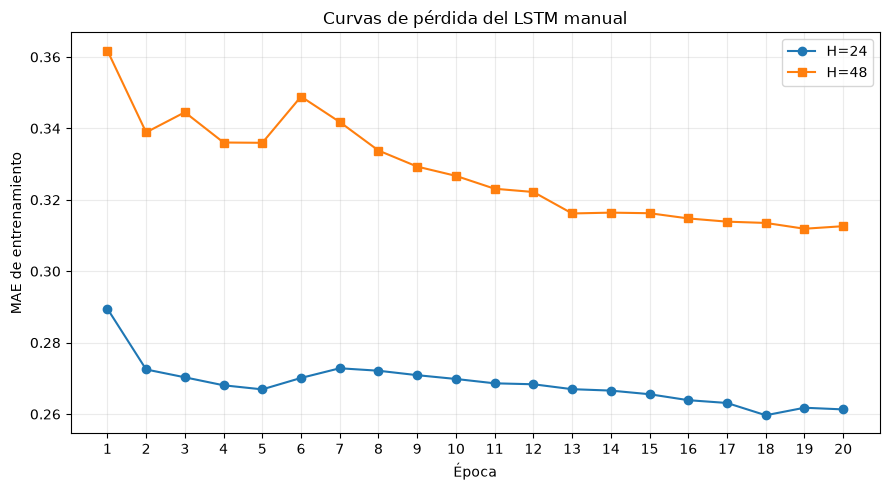

In [10]:
epochs = torch.arange(1, 21)
plt.figure(figsize=(9, 5))
plt.plot(epochs.numpy(), loss_lstm_24, marker='o', label='H=24')
plt.plot(epochs.numpy(), loss_lstm_48, marker='s', label='H=48')
plt.xlabel('Época')
plt.ylabel('MAE de entrenamiento')
plt.title('Curvas de pérdida del LSTM manual')
plt.xticks(epochs.numpy())
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Verificación Task 2

In [11]:
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"
# Verificar que el modelo supera al naive en H=24
mae_lstm_24 = torch.abs(y_vl_24 - pred_vl_24).mean().item()
assert mae_lstm_24 < naive_mae * 1.1, \
f"LSTM H=24 no supera al naive: {mae_lstm_24:.4f} vs {naive_mae:.4f}"
print(f"Task 2: CORRECTO")
print(f" LSTM H=24: MAE={mae_lstm_24:.4f}, ratio={mae_lstm_24/naive_mae:.3f}")

Task 2: CORRECTO
 LSTM H=24: MAE=0.2161, ratio=1.082
